<a href="https://colab.research.google.com/github/4ffan-x/ECG-model/blob/main/Notebook/ECG_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.applications import ResNet50
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import cv2
import os
from PIL import Image
from google.colab.patches import cv2_imshow
import zipfile
import matplotlib.image as mpimg
from tensorflow.keras import layers, models
import keras
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Activation, Dropout, BatchNormalization, Flatten, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import pickle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download khyeh0719/ptb-xl-dataset

Dataset URL: https://www.kaggle.com/datasets/khyeh0719/ptb-xl-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
ptb-xl-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
with zipfile.ZipFile('/content/ptb-xl-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [5]:
df = pd.read_csv('/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv')
display(df.head())

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [6]:
df.tail()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
21832,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,...,True,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,True,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr
21834,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,...,True,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,True,NaN,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr
21836,21837,11744.0,68.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-11 16:43:01,...,True,NaN,", I-AVL,",NaN,NaN,NaN,NaN,9,records100/21000/21837_lr,records500/21000/21837_hr


In [7]:
scp_df = pd.read_csv('/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/scp_statements.csv', index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]

print("Columns in scp_df:", scp_df.columns.tolist())
print("Head of scp_df:")
display(scp_df.head())

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in scp_df.index:
            # Corrected to use 'diagnostic_class' as 'diagnostic_superclass' is not present
            tmp.append(scp_df.loc[key]['diagnostic_class'])
    return list(set(tmp))

df['diagnostic_superclass'] = df.scp_codes.apply(lambda x: aggregate_diagnostic(eval(x)))

display(df.head())

Columns in scp_df: ['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']
Head of scp_df:


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]


In [8]:
print(df.info())

# Explode the diagnostic_superclass column to handle lists of classes
exploded_superclasses = df['diagnostic_superclass'].explode()

print('\nNumber of unique diagnostic superclasses:', exploded_superclasses.nunique())
print('\nDistribution of diagnostic superclasses:')
display(exploded_superclasses.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 21837 entries, 0 to 21836
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21837 non-null  int64  
 1   patient_id                    21837 non-null  float64
 2   age                           21748 non-null  float64
 3   sex                           21837 non-null  int64  
 4   height                        6983 non-null   float64
 5   weight                        9429 non-null   float64
 6   nurse                         20328 non-null  float64
 7   site                          21819 non-null  float64
 8   device                        21837 non-null  str    
 9   recording_date                21837 non-null  str    
 10  report                        21837 non-null  str    
 11  scp_codes                     21837 non-null  str    
 12  heart_axis                    13332 non-null  str    
 13  infarction_s

diagnostic_superclass
NORM    9528
MI      5486
STTC    5250
CD      4907
HYP     2655
Name: count, dtype: int64

In [9]:
df.shape, scp_df.shape

((21837, 29), (44, 12))

In [10]:
scp_df.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [11]:
scp_df.info()

<class 'pandas.DataFrame'>
Index: 44 entries, NDT to 2AVB
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   description                    44 non-null     str    
 1   diagnostic                     44 non-null     float64
 2   form                           4 non-null      float64
 3   rhythm                         0 non-null      float64
 4   diagnostic_class               44 non-null     str    
 5   diagnostic_subclass            44 non-null     str    
 6   Statement Category             44 non-null     str    
 7   SCP-ECG Statement Description  44 non-null     str    
 8   AHA code                       22 non-null     float64
 9   aECG REFID                     12 non-null     str    
 10  CDISC Code                     13 non-null     str    
 11  DICOM Code                     9 non-null      str    
dtypes: float64(4), str(8)
memory usage: 10.6 KB


In [12]:
print(df.columns)

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr',
       'diagnostic_superclass'],
      dtype='str')


In [13]:
display(df['scp_codes'].head())

0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: str

In [14]:
df.isnull().sum() #bhot missing values but not important ones

ecg_id                              0
patient_id                          0
age                                89
sex                                 0
height                          14854
weight                          12408
nurse                            1509
site                               18
device                              0
recording_date                      0
report                              0
scp_codes                           0
heart_axis                       8505
infarction_stadium1             16211
infarction_stadium2             21734
validated_by                     9411
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
baseline_drift                  20230
static_noise                    18575
burst_noise                     21224
electrodes_problems             21807
extra_beats                     19883
pacemaker                       21544
strat_fold                          0
filename_lr 

In [15]:
scp_df.isnull().sum() #some missing values

description                       0
diagnostic                        0
form                             40
rhythm                           44
diagnostic_class                  0
diagnostic_subclass               0
Statement Category                0
SCP-ECG Statement Description     0
AHA code                         22
aECG REFID                       32
CDISC Code                       31
DICOM Code                       35
dtype: int64

In [16]:
display(exploded_superclasses.value_counts())#all the super are not equal

diagnostic_superclass
NORM    9528
MI      5486
STTC    5250
CD      4907
HYP     2655
Name: count, dtype: int64

#### Distribution of Diagnostic Superclasses (Pie Chart)

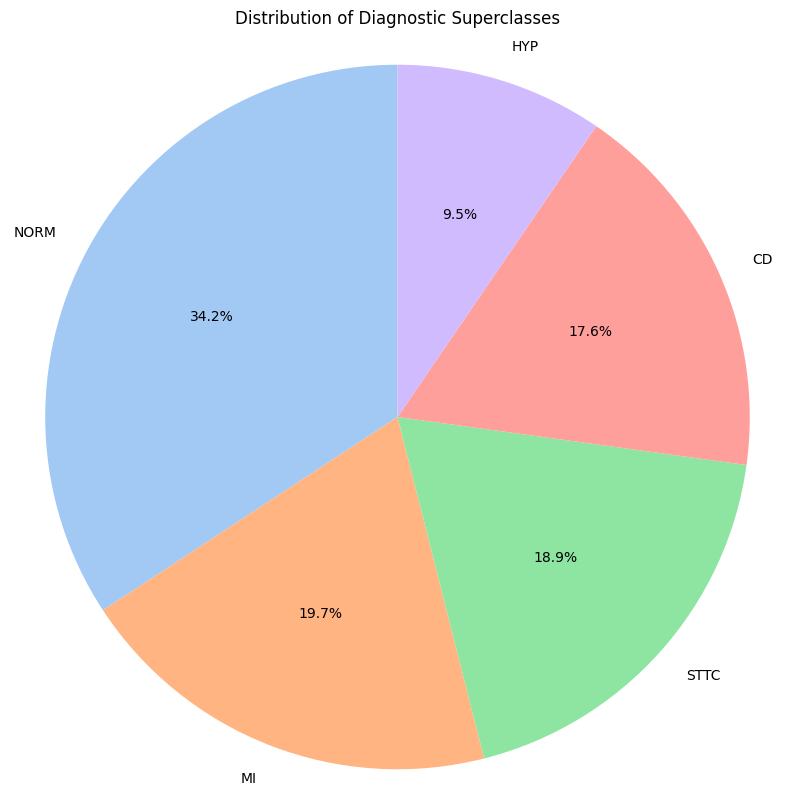

In [17]:
counts = exploded_superclasses.value_counts()
labels = counts.index
values = counts.values

plt.figure(figsize=(10, 10))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Diagnostic Superclasses')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

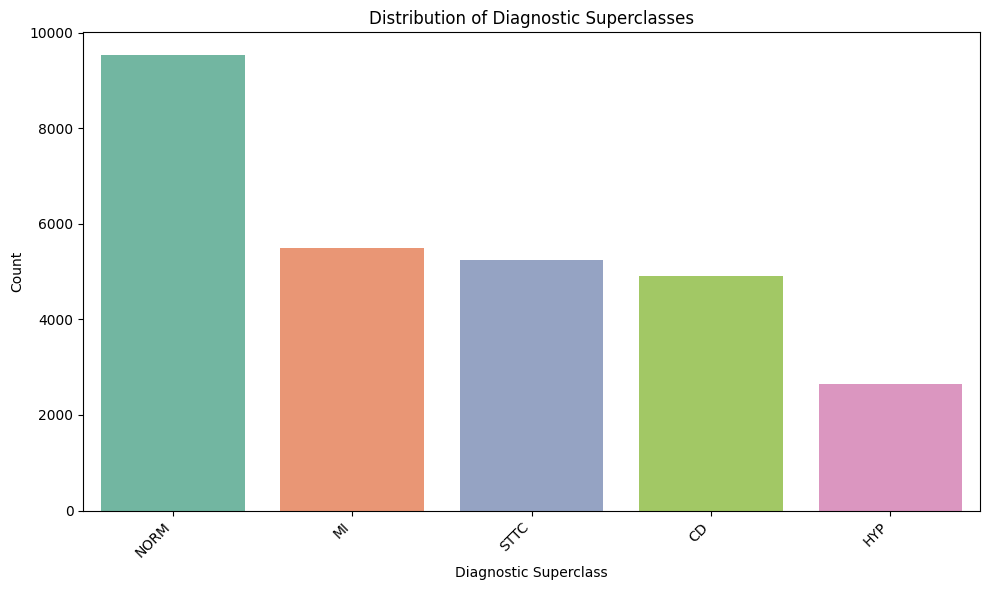

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x='diagnostic_superclass', data=pd.DataFrame({'diagnostic_superclass': exploded_superclasses.reset_index(drop=True)}), palette='Set2', hue='diagnostic_superclass', legend=False, order=exploded_superclasses.value_counts().index)
plt.title('Distribution of Diagnostic Superclasses')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
plot_df = df[['age', 'sex', 'device', 'diagnostic_superclass']].explode('diagnostic_superclass').copy()
plot_df.reset_index(drop=True, inplace=True)

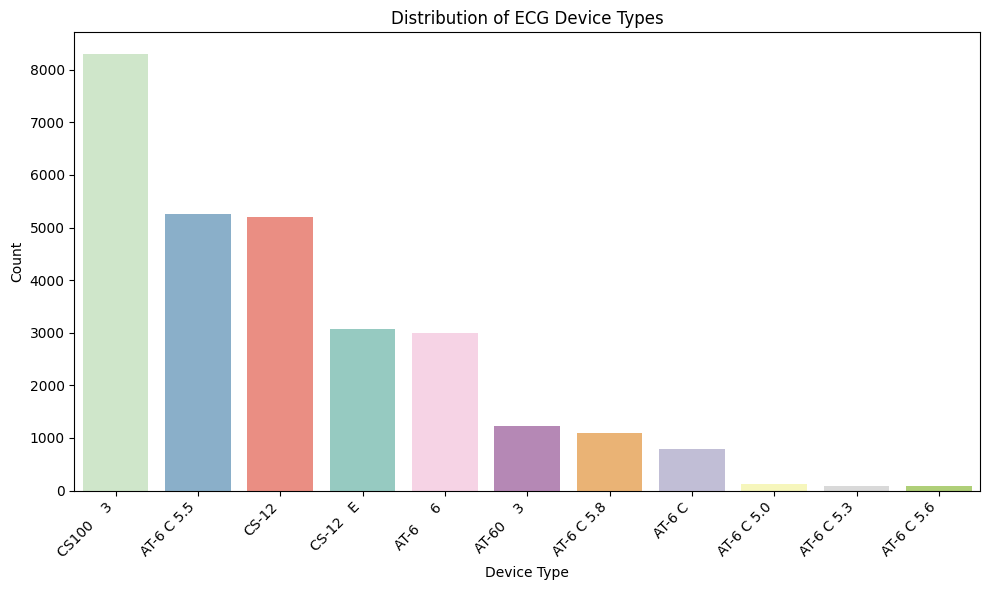

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='device', data=plot_df, palette='Set3', hue='device', legend=False, order=plot_df['device'].value_counts().index)
plt.title('Distribution of ECG Device Types')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

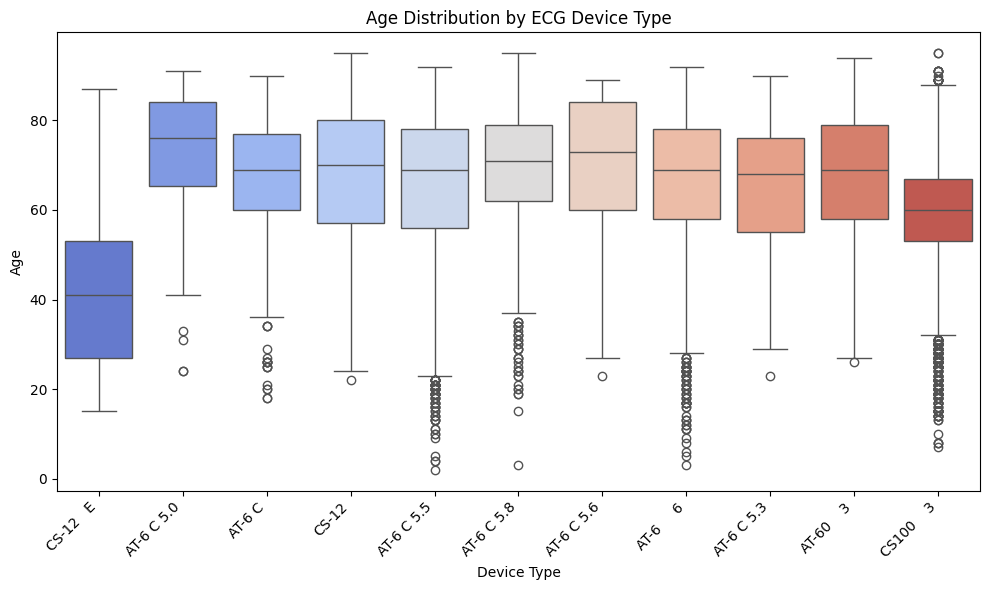

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='device', y='age', data=plot_df, palette='coolwarm', hue='device', legend=False)
plt.title('Age Distribution by ECG Device Type')
plt.xlabel('Device Type')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualizing a Sample ECG Signal

To visualize the signal data, we'll first load a sample high-resolution ECG signal. The `filename_hr` column in our DataFrame contains paths to these signal files, which are stored as NumPy arrays. Each file represents a single ECG recording across multiple leads.

In [22]:
!pip install wfdb

Attempting to load record from: /content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records500/00000/00001_hr
Sample signal shape: (5000, 12) (Timepoints, Leads)


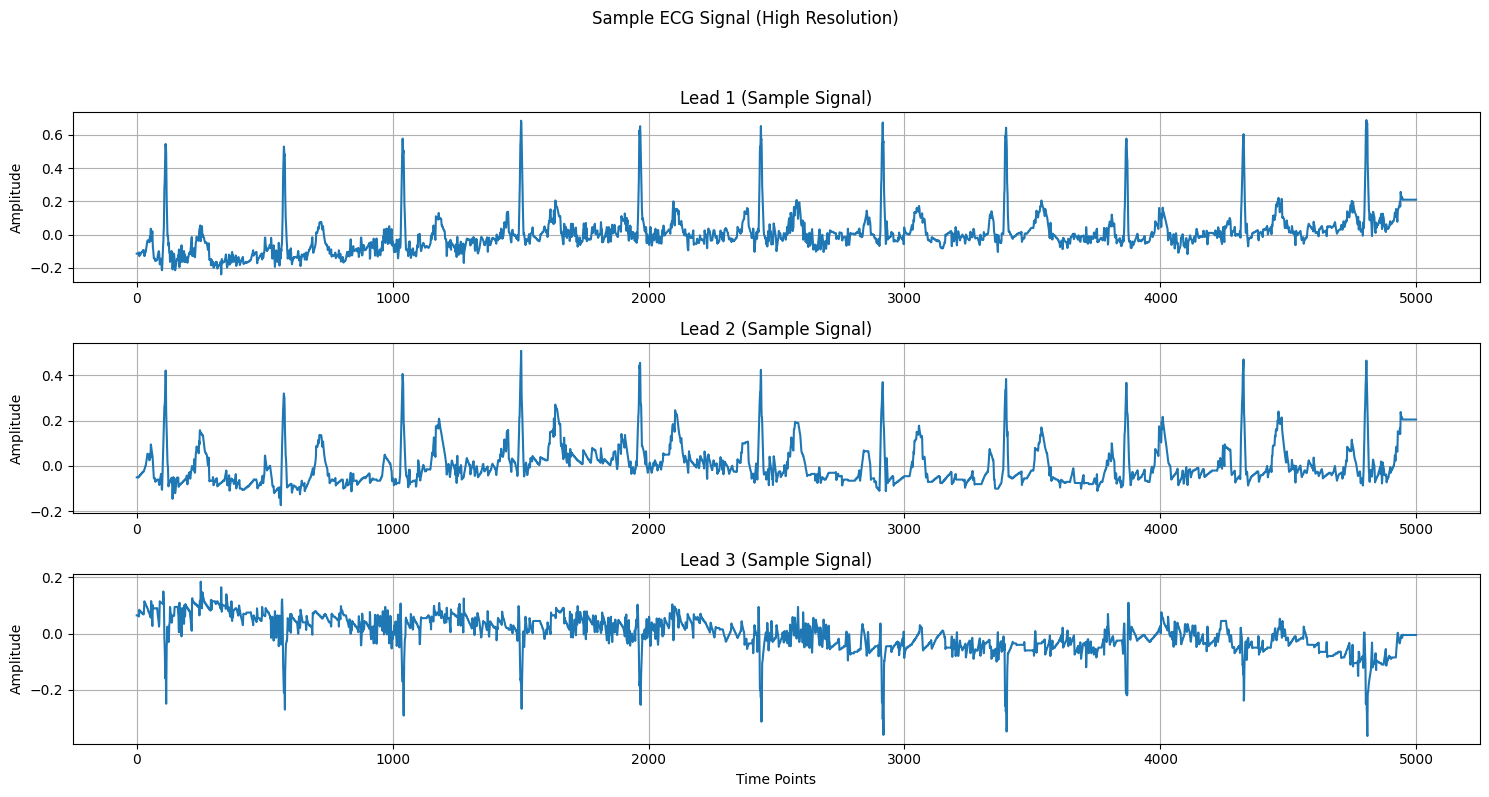

In [23]:
import os
import wfdb # Often used for loading Physionet data
import numpy as np # Ensure numpy is imported for general array manipulation
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

# Construct the base path to the signal files
base_path = '/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

# Get the first high-resolution filename from the DataFrame
sample_filename_hr = df.loc[0, 'filename_hr'] # e.g., 'records500/00000/00001_hr'

# Construct the full record path expected by wfdb.rdsamp (without .dat or .hea extension)
full_record_path = os.path.join(base_path, sample_filename_hr)

print(f"Attempting to load record from: {full_record_path}")

try:
    # Load the signal data using wfdb.rdsamp
    # wfdb.rdsamp returns a tuple: (samples, metadata)
    sample_signal, metadata = wfdb.rdsamp(full_record_path)
    print(f"Sample signal shape: {sample_signal.shape} (Timepoints, Leads)")
    # print(f"Metadata: {metadata}") # Uncomment to see full metadata

    # Plot the first few leads of the sample signal
    plt.figure(figsize=(15, 8))
    num_leads_to_plot = min(sample_signal.shape[1], 3) # Plot up to 3 leads for illustration
    for i in range(num_leads_to_plot):
        plt.subplot(num_leads_to_plot, 1, i + 1)
        plt.plot(sample_signal[:, i])
        plt.title(f'Lead {i+1} (Sample Signal)')
        plt.ylabel('Amplitude')
        plt.grid(True)
    plt.xlabel('Time Points')
    plt.suptitle('Sample ECG Signal (High Resolution)', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [24]:
print(f"Metadata: {metadata}")

Metadata: {'fs': 500, 'sig_len': 5000, 'n_sig': 12, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], 'comments': []}


## Stage 3: Load ECG Waveform Files

In [25]:
def load_ecg(path):
    signal, meta = wfdb.rdsamp(path)
    return signal

base_path = '/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

# --- MODIFIED: Use 'filename_lr' for low-resolution files to save memory ---
df['full_path'] = df['filename_lr'].apply(lambda x: os.path.join(base_path, x))

print("Loading all low-resolution ECG signals...")

# Determine the shape of a single signal to pre-allocate X
# Load the first signal to get its shape
sample_signal, _ = wfdb.rdsamp(df.loc[0, 'full_path'])
signal_shape = sample_signal.shape # Expected: (1000, 12) for low-resolution

# Pre-allocate the X array with the correct dimensions and data type
X = np.zeros((len(df), signal_shape[0], signal_shape[1]), dtype=np.float32)

for i, row in df.iterrows():
    signal = load_ecg(row['full_path'])
    X[i] = signal

print(f"All ECG signals loaded. Shape of X: {X.shape}")
print(f"Data type of X: {X.dtype}")

Loading all low-resolution ECG signals...
All ECG signals loaded. Shape of X: (21837, 1000, 12)
Data type of X: float32


In [26]:
print("Applying Z-score normalization to ECG signals using strict in-place operations...")

# Calculate mean and standard deviation across the time and lead dimensions for each sample
# Keep dimensions for broadcasting: (num_samples, 1, 1)
mean_X = X.mean(axis=(1, 2), keepdims=True)
std_X = X.std(axis=(1, 2), keepdims=True)

# Use numpy.subtract and numpy.divide with 'out' argument to perform operations strictly in-place
# This avoids creating temporary large arrays during intermediate calculations.

# First, subtract mean: X = X - mean_X
np.subtract(X, mean_X, out=X)

# Then, divide by std: X = X / (std_X + 1e-8)
# Create a small temporary array for (std_X + 1e-8) before division
std_X_plus_epsilon = std_X + 1e-8
np.divide(X, std_X_plus_epsilon, out=X)

print("Z-score normalization complete.")
print(f"Shape of normalized X: {X.shape}")
print(f"Example of normalized signal stats (first signal):\n Mean: {X[0].mean():.4f}, Std: {X[0].std():.4f}")

Applying Z-score normalization to ECG signals using strict in-place operations...
Z-score normalization complete.
Shape of normalized X: (21837, 1000, 12)
Example of normalized signal stats (first signal):
 Mean: 0.0000, Std: 1.0000


In [27]:
# Get all unique diagnostic superclasses from the exploded series, dropping any NaN values
all_superclasses = sorted(exploded_superclasses.dropna().unique())
num_classes = len(all_superclasses)

print(f"Found {num_classes} unique diagnostic superclasses: {all_superclasses}")

# Create a mapping from superclass name to its index
superclass_to_index = {superclass: i for i, superclass in enumerate(all_superclasses)}

# Initialize an empty array for one-hot encoded labels
# Shape will be (num_samples, num_classes)
y_labels = np.zeros((len(df), num_classes), dtype=np.int8)

# Populate the y_labels array
for i, superclasses_list in enumerate(df['diagnostic_superclass']):
    # Ensure superclasses_list is iterable and not NaN
    if isinstance(superclasses_list, list):
        for sc in superclasses_list:
            if sc in superclass_to_index:
                y_labels[i, superclass_to_index[sc]] = 1

print(f"Shape of one-hot encoded labels (y_labels): {y_labels.shape}")
print("First 5 rows of y_labels (one-hot encoded):")
display(pd.DataFrame(y_labels, columns=all_superclasses).head())

Found 5 unique diagnostic superclasses: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
Shape of one-hot encoded labels (y_labels): (21837, 5)
First 5 rows of y_labels (one-hot encoded):


,CD,HYP,MI,NORM,STTC
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


In [28]:
from sklearn.model_selection import train_test_split

# Original indices for the full dataset
original_indices = df.index.values

# First split: 80% for training+validation, 20% for test
# We split the original indices and use them to get the corresponding 'strat_fold' values
indices_train_val, indices_test = train_test_split(original_indices, test_size=0.2, random_state=42, stratify=df['strat_fold'])

# Second split: 10% for validation (from the 80% train_val set), 70% for actual training
# This results in a 70/10/20 split for train/val/test
strat_fold_train_val = df.loc[indices_train_val, 'strat_fold']
indices_train, indices_val = train_test_split(
    indices_train_val, test_size=0.125, random_state=42, stratify=strat_fold_train_val
)

print(f"Number of training samples: {len(indices_train)}")
print(f"Number of validation samples: {len(indices_val)}")
print(f"Number of test samples: {len(indices_test)}")

Number of training samples: 15285
Number of validation samples: 2184
Number of test samples: 4368


### Stage 4.4: Create TensorFlow `tf.data.Dataset` Objects

To efficiently handle large datasets and prevent memory issues during training, we will create `tf.data.Dataset` objects for our training, validation, and test sets. This approach allows us to load data in batches on-the-fly, rather than keeping the entire dataset in memory.

In [29]:
def create_tf_dataset(indices, X_data, y_data, batch_size=32, shuffle=True):
    # Extract the actual data points using the indices
    dataset_X = X_data[indices]
    dataset_y = y_data[indices]

    # Create a tf.data.Dataset from the numpy arrays
    dataset = tf.data.Dataset.from_tensor_slices((dataset_X, dataset_y))

    # Shuffle and batch the dataset
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(indices))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

BATCH_SIZE = 64 # You can adjust this batch size based on your GPU memory

# Create datasets
train_dataset = create_tf_dataset(indices_train, X, y_labels, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(indices_val, X, y_labels, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = create_tf_dataset(indices_test, X, y_labels, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train Dataset: {train_dataset}")
print(f"Validation Dataset: {val_dataset}")
print(f"Test Dataset: {test_dataset}")

Train Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1000, 12), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int8, name=None))>
Validation Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1000, 12), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int8, name=None))>
Test Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1000, 12), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int8, name=None))>


In [30]:
def build_cnn_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(64, 7, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="sigmoid")(x) # Corrected for multi-label
    return tf.keras.Model(inputs, outputs)


In [31]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

for X_batch, y_batch in train_dataset.take(1):
    input_shape = X_batch.shape[1:]
    break

num_classes = y_labels.shape[1]

print(f"Input shape for the model: {input_shape}")
print(f"Number of output classes: {num_classes}")

# Instantiate the model using the new functional API function
model = build_cnn_model(input_shape=input_shape, num_classes=num_classes)

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Input shape for the model: (1000, 12)
Number of output classes: 5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 64)       │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 125, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,309 (1.44 MB)

 Trainable params: 376,901 (1.44 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Define ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks defined: EarlyStopping and ModelCheckpoint.")

Callbacks defined: EarlyStopping and ModelCheckpoint.


In [33]:
EPOCHS = 30

print(f"Starting model training for {EPOCHS} epochs...")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("Model training complete.")

Starting model training for 25 epochs...
Epoch 1/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5736 - loss: 0.4126
Epoch 1: val_accuracy improved from None to 0.63645, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.6142 - loss: 0.3688 - val_accuracy: 0.6364 - val_loss: 0.3598
Epoch 2/25
237/239 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6609 - loss: 0.3212
Epoch 2: val_accuracy improved from 0.63645 to 0.65751, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6581 - loss: 0.3190 - val_accuracy: 0.6575 - val_loss: 0.3005
Epoch 3/25
237/239 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6711 - loss: 0.3045
Epoch 3: val_accuracy improved from 0.65751 to 0.68773, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
239/239 ━━━━━━━━━

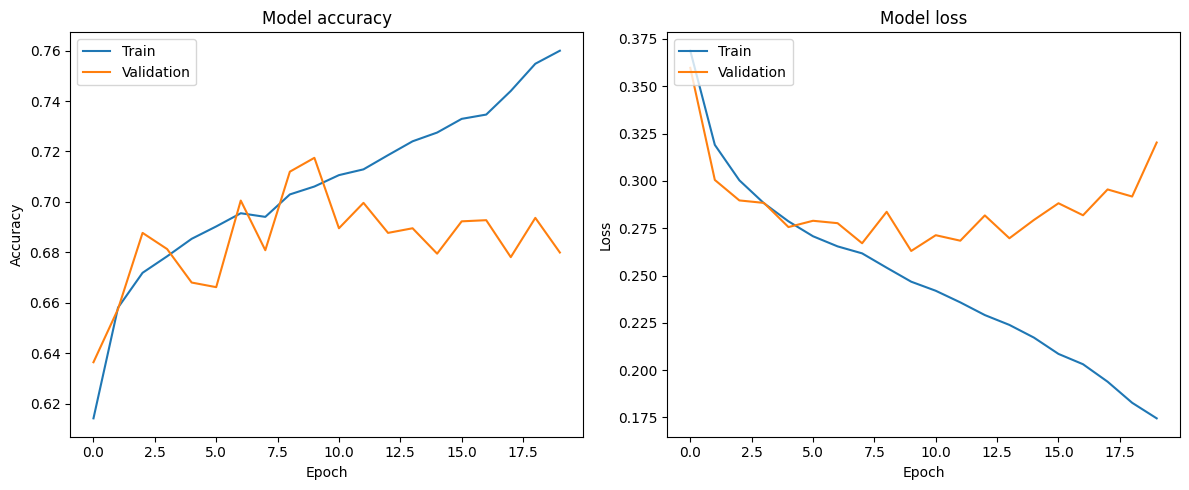

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
from tensorflow.keras.models import load_model

# Load the best model saved by ModelCheckpoint
best_model = load_model('best_cnn_model.keras')

print("Best model loaded successfully.")

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Make predictions on the test dataset
print("Making predictions on the test set...")
y_pred_proba = best_model.predict(test_dataset)
print("Predictions complete.")

Best model loaded successfully.
Making predictions on the test set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Predictions complete.


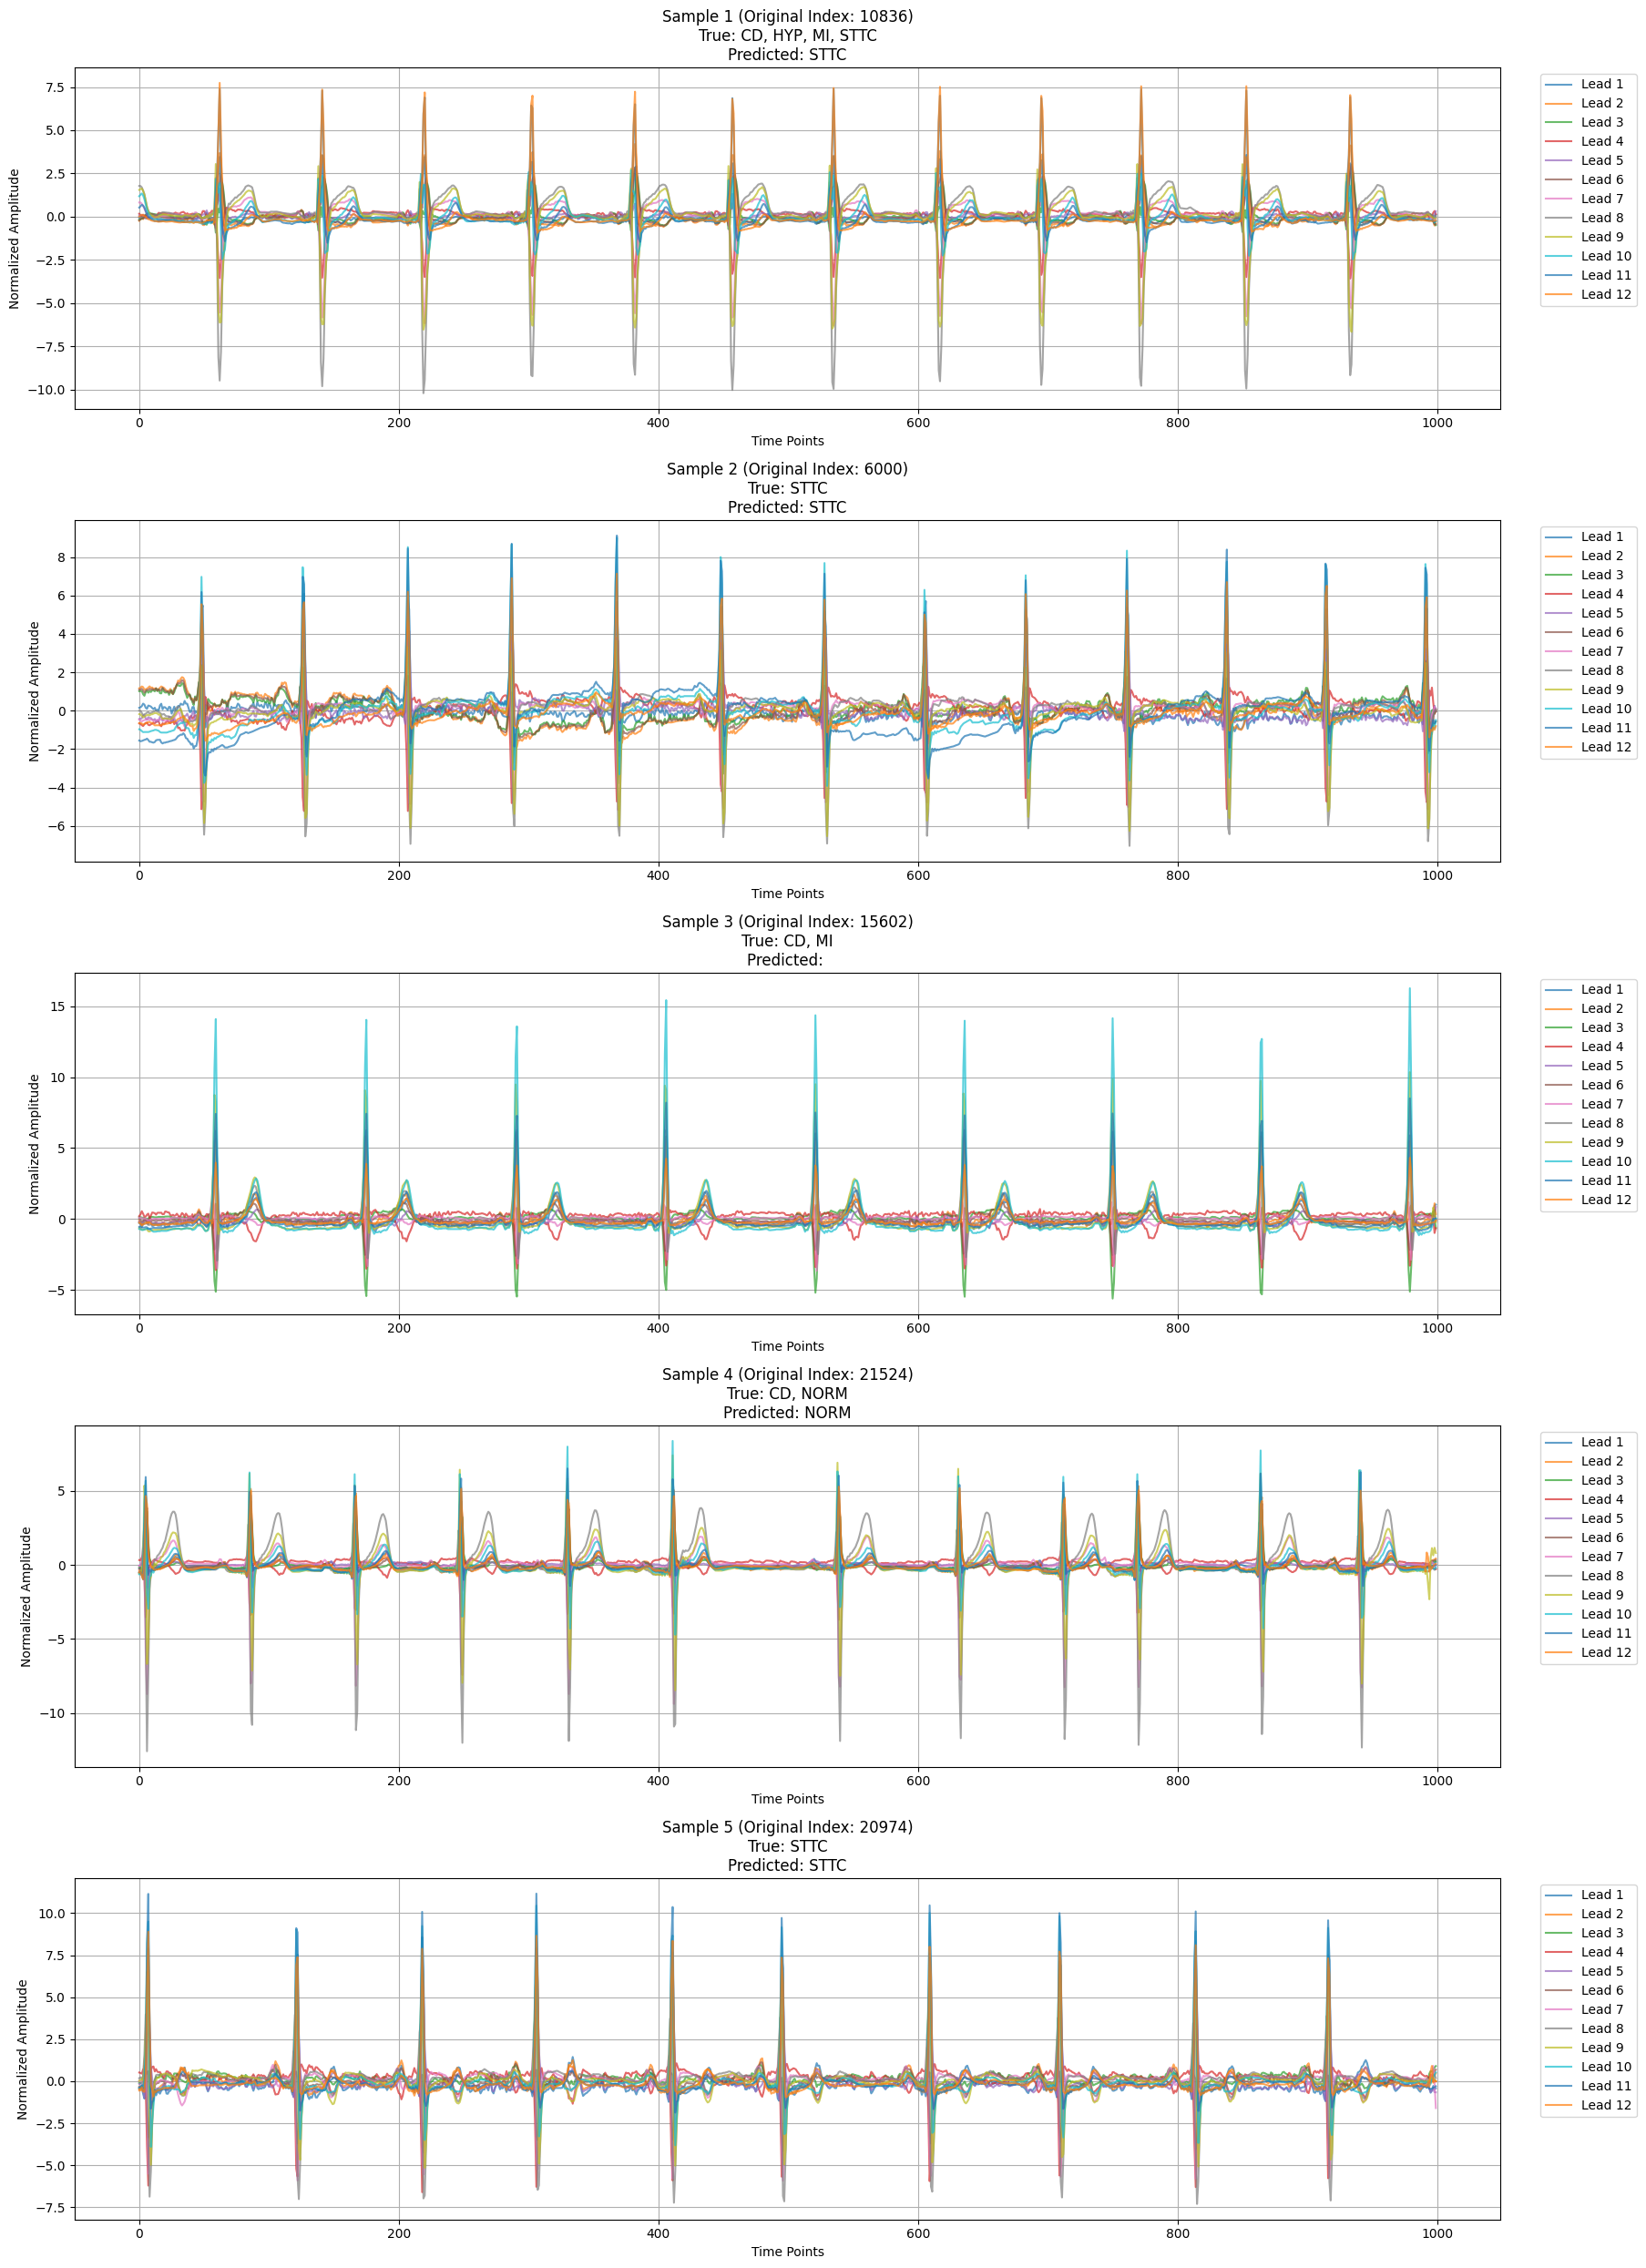

In [51]:
num_samples_to_visualize = 5

test_indices = indices_test

np.random.seed(42)
sample_test_indices = np.random.choice(len(test_indices), num_samples_to_visualize, replace=False)

y_pred = (y_pred_proba > 0.5).astype(int)

plt.figure(figsize=(18, 5 * num_samples_to_visualize))

for i, idx_in_test_set in enumerate(sample_test_indices):
    original_idx = test_indices[idx_in_test_set]
    sample_ecg = X[original_idx]
    true_labels_one_hot = y_true[idx_in_test_set]
    pred_labels_one_hot = y_pred[idx_in_test_set]

    # Convert one-hot to class names
    true_labels = [all_superclasses[j] for j, val in enumerate(true_labels_one_hot) if val == 1]
    pred_labels = [all_superclasses[j] for j, val in enumerate(pred_labels_one_hot) if val == 1]

    plt.subplot(num_samples_to_visualize, 1, i + 1)
    for lead_idx in range(sample_ecg.shape[1]):
        plt.plot(sample_ecg[:, lead_idx], alpha=0.7, label=f'Lead {lead_idx+1}')

    plt.title(f"Sample {i+1} (Original Index: {original_idx})\nTrue: {', '.join(true_labels)}\nPredicted: {', '.join(pred_labels)}")
    plt.xlabel("Time Points")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()

Please enter an ECG ID to analyze (e.g., 11, 25, 100): 1
Attempting to predict for ecg_id: 1

--- Predictions for ECG ID: 1 ---
  CD: 0.0090
  HYP: 0.0009
  MI: 0.0044
  NORM: 0.9690
  STTC: 0.0114


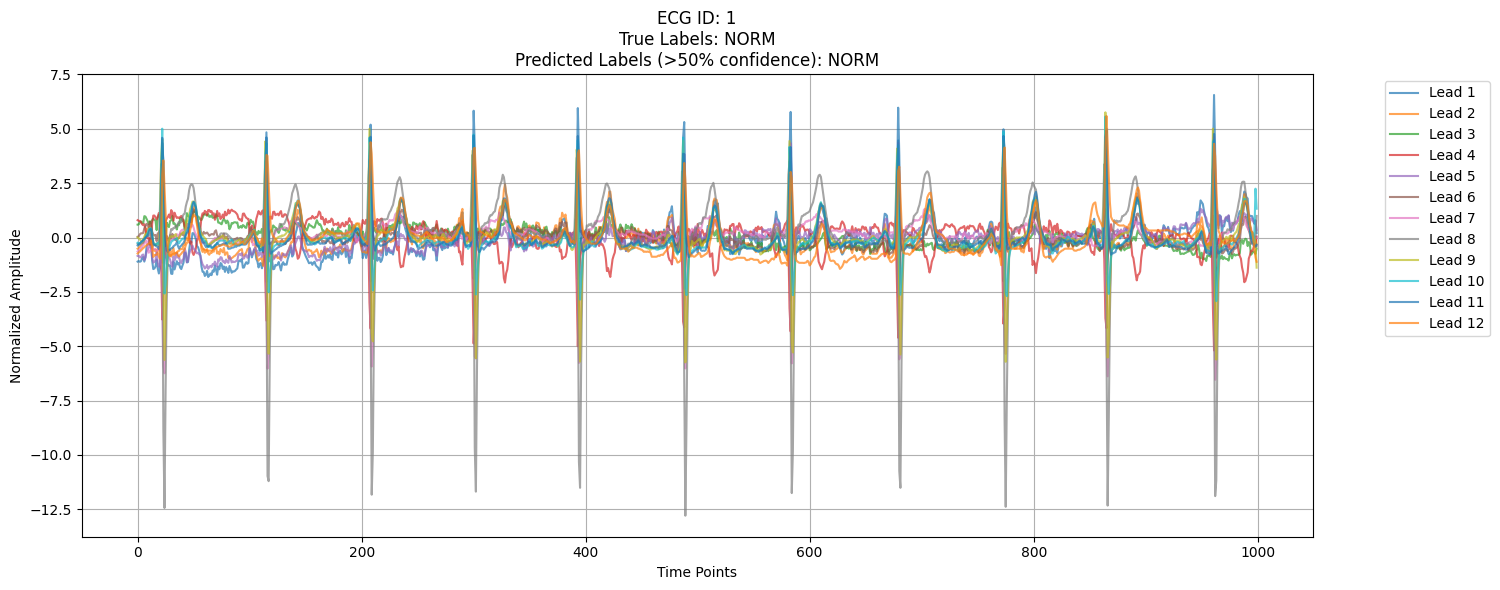


Detected Labels: ['NORM']
Confidence Scores: ['0.97']


In [54]:
def ecg_detection_system(ecg_id_input, model, all_superclasses, X_data, df, threshold=0.5):
    original_idx = df[df['ecg_id'] == ecg_id_input].index
    if original_idx.empty:
        print(f"Error: ecg_id {ecg_id_input} not found in the DataFrame.")
        return [], []
    original_idx = original_idx[0]

    ecg_signal = X_data[original_idx]

    ecg_input = np.expand_dims(ecg_signal, axis=0)

    predictions = model.predict(ecg_input, verbose=0)[0]

    predicted_labels = []
    confidence_scores = []

    print(f"\n--- Predictions for ECG ID: {ecg_id_input} ---")
    for i, prob in enumerate(predictions):
        class_name = all_superclasses[i]
        print(f"  {class_name}: {prob:.4f}")
        if prob >= threshold:
            predicted_labels.append(class_name)
            confidence_scores.append(prob)

    plt.figure(figsize=(15, 6))
    for lead_idx in range(ecg_signal.shape[1]):
        plt.plot(ecg_signal[:, lead_idx], alpha=0.7, label=f'Lead {lead_idx+1}')

    true_labels_list = df.loc[original_idx, 'diagnostic_superclass']
    true_labels_str = ', '.join(true_labels_list) if true_labels_list else 'None'

    title_str = f"ECG ID: {ecg_id_input}\nTrue Labels: {true_labels_str}\nPredicted Labels (>{(threshold*100):.0f}% confidence): {', '.join(predicted_labels) if predicted_labels else 'None'}"
    plt.title(title_str)
    plt.xlabel("Time Points")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

    return predicted_labels, confidence_scores


user_input_ecg_id = input("Please enter an ECG ID to analyze (e.g., 11, 25, 100): ")

try:
    example_ecg_id = int(user_input_ecg_id)
except ValueError:
    print("Invalid input. Please enter a valid integer for ECG ID.")
    example_ecg_id = None

if example_ecg_id is not None:
    print(f"Attempting to predict for ecg_id: {example_ecg_id}")
    predicted_labels, confidences = ecg_detection_system(example_ecg_id, best_model, all_superclasses, X, df)

    if predicted_labels:
        print(f"\nDetected Labels: {predicted_labels}")
        print(f"Confidence Scores: {[f'{c:.2f}' for c in confidences]}")
    else:
        print("\nNo classes detected above the threshold.")

In [41]:
from scipy.signal import resample
import os

def preprocess_external_ecg(file_path, target_fs=100, target_length=1000):
    try:
        base_record_path = file_path.rsplit('.', 1)[0] if file_path.endswith('.dat') else file_path

        signal, metadata = wfdb.rdsamp(base_record_path)
        original_fs = metadata['fs']
        signal_names = metadata['sig_name']

        if original_fs != target_fs:
            num_samples_resampled = int(signal.shape[0] * (target_fs / original_fs))
            signal = resample(signal, num_samples_resampled, axis=0)

        if signal.shape[0] > target_length:
            signal = signal[:target_length, :]
        elif signal.shape[0] < target_length:
            padding = np.zeros((target_length - signal.shape[0], signal.shape[1]))
            signal = np.vstack((signal, padding))

        mean_signal = signal.mean(axis=(0, 1), keepdims=True)
        std_signal = signal.std(axis=(0, 1), keepdims=True)
        normalized_signal = (signal - mean_signal) / (std_signal + 1e-8)

        return normalized_signal, signal_names

    except Exception as e:
        print(f"Error processing external ECG file {file_path}: {e}")
        return None, None

def ecg_detection_system_from_file_path(file_path, model, all_superclasses, threshold=0.5):
    processed_signal, signal_names = preprocess_external_ecg(file_path)

    if processed_signal is None:
        return [], []

    ecg_input = np.expand_dims(processed_signal, axis=0)

    predictions = model.predict(ecg_input, verbose=0)[0]

    predicted_labels = []
    confidence_scores = []

    print(f"\n--- Predictions for ECG from: {file_path} ---")
    for i, prob in enumerate(predictions):
        class_name = all_superclasses[i]
        print(f"  {class_name}: {prob:.4f}")
        if prob >= threshold:
            predicted_labels.append(class_name)
            confidence_scores.append(prob)

    plt.figure(figsize=(15, 6))
    if signal_names:
        for lead_idx in range(processed_signal.shape[1]):
            plt.plot(processed_signal[:, lead_idx], alpha=0.7, label=signal_names[lead_idx])
    else:
        for lead_idx in range(processed_signal.shape[1]):
            plt.plot(processed_signal[:, lead_idx], alpha=0.7, label=f'Lead {lead_idx+1}')

    title_str = f"ECG from: {os.path.basename(file_path)}\nPredicted Labels (>{threshold*100:.0f}% confidence): {', '.join(predicted_labels) if predicted_labels else 'None'}"
    plt.title(title_str)
    plt.xlabel("Time Points (normalized)")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

    return predicted_labels, confidence_scores

base_ecg_path = '/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

user_input_file_path = input(
    "Please enter the full path to an ECG .dat file (e.g., "
    f"'{base_ecg_path}records100/00000/00001_lr'): "
)

if user_input_file_path:
    print(f"Attempting to predict for ECG file: {user_input_file_path}")
    predicted_labels, confidences = ecg_detection_system_from_file_path(
        user_input_file_path, best_model, all_superclasses
    )

    if predicted_labels:
        print(f"\nDetected Labels: {predicted_labels}")
        print(f"Confidence Scores: {[f'{c:.2f}' for c in confidences]}")
    else:
        print("\nNo classes detected above the threshold or error in processing file.")
else:
    print("No file path provided. Skipping prediction.")

Please enter the full path to an ECG .dat file (e.g., '/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records100/00000/00001_lr'): 
No file path provided. Skipping prediction.


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

y_pred = (y_pred_proba > 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=all_superclasses))

print("\n--- F1-score (micro) ---")
print(f1_score(y_true, y_pred, average='micro'))

print("\n--- AUROC (macro) ---")
try:
    auroc = roc_auc_score(y_true, y_pred_proba, average='macro', multi_class='ovr')
    print(auroc)
except ValueError as e:
    print(f"Could not compute AUROC (macro) due to: {e}. This often happens if one class has no positive samples.")
    print("Attempting to compute per-class AUROC...")
    per_class_auroc = []
    for i, class_name in enumerate(all_superclasses):
        if np.sum(y_true[:, i]) > 0 and np.sum(1 - y_true[:, i]) > 0:
            per_class_auroc.append(roc_auc_score(y_true[:, i], y_pred_proba[:, i]))
        else:
            per_class_auroc.append(np.nan)
    print(f"Per-class AUROC: {dict(zip(all_superclasses, per_class_auroc))}")


--- Classification Report ---
              precision    recall  f1-score   support

          CD       0.80      0.76      0.78       991
         HYP       0.72      0.35      0.47       526
          MI       0.80      0.71      0.75      1088
        NORM       0.87      0.87      0.87      1916
        STTC       0.78      0.71      0.74      1046

   micro avg       0.82      0.74      0.78      5567
   macro avg       0.79      0.68      0.72      5567
weighted avg       0.81      0.74      0.77      5567
 samples avg       0.78      0.75      0.75      5567


--- F1-score (micro) ---
0.7776310826103358

--- AUROC (macro) ---
0.9286525313815556


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Confusion Matrices (One-vs-Rest) ---


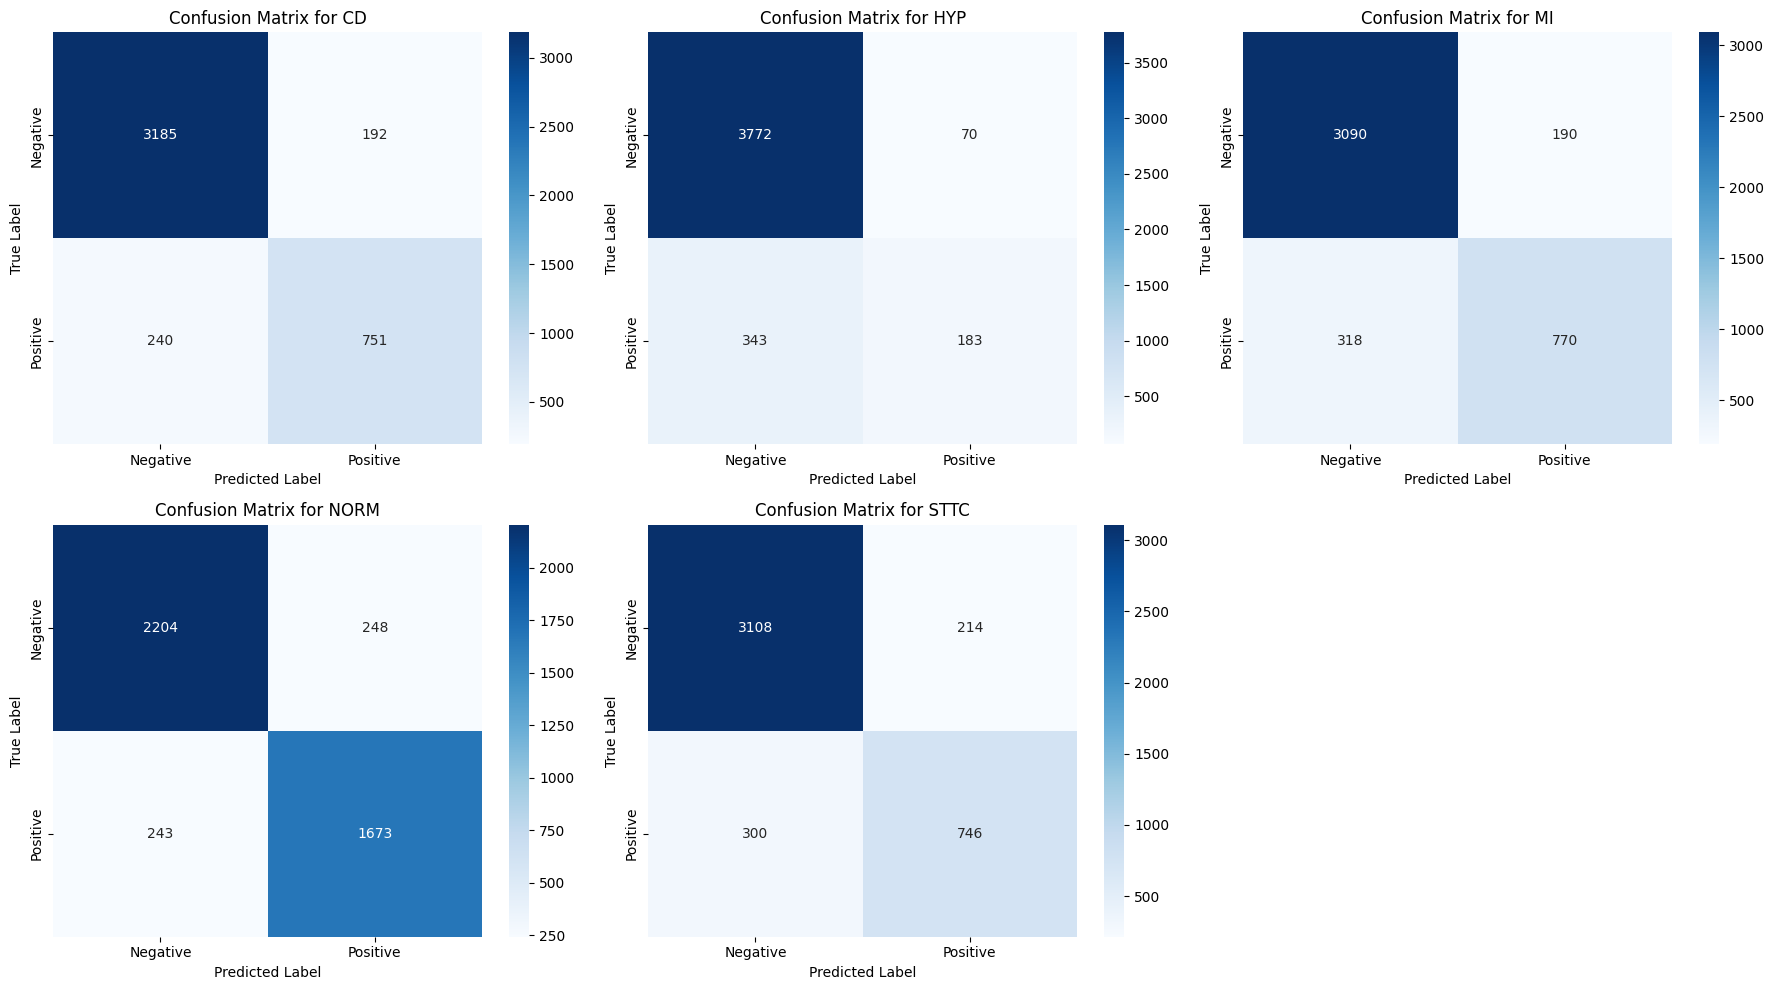

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("\n--- Confusion Matrices (One-vs-Rest) ---")

# Calculate optimal grid size for subplots
num_cols = min(num_classes, 3)
num_rows = int(np.ceil(num_classes / num_cols))

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, class_name in enumerate(all_superclasses):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    plt.subplot(num_rows, num_cols, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix for {class_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()


--- ROC Curves (One-vs-Rest) ---


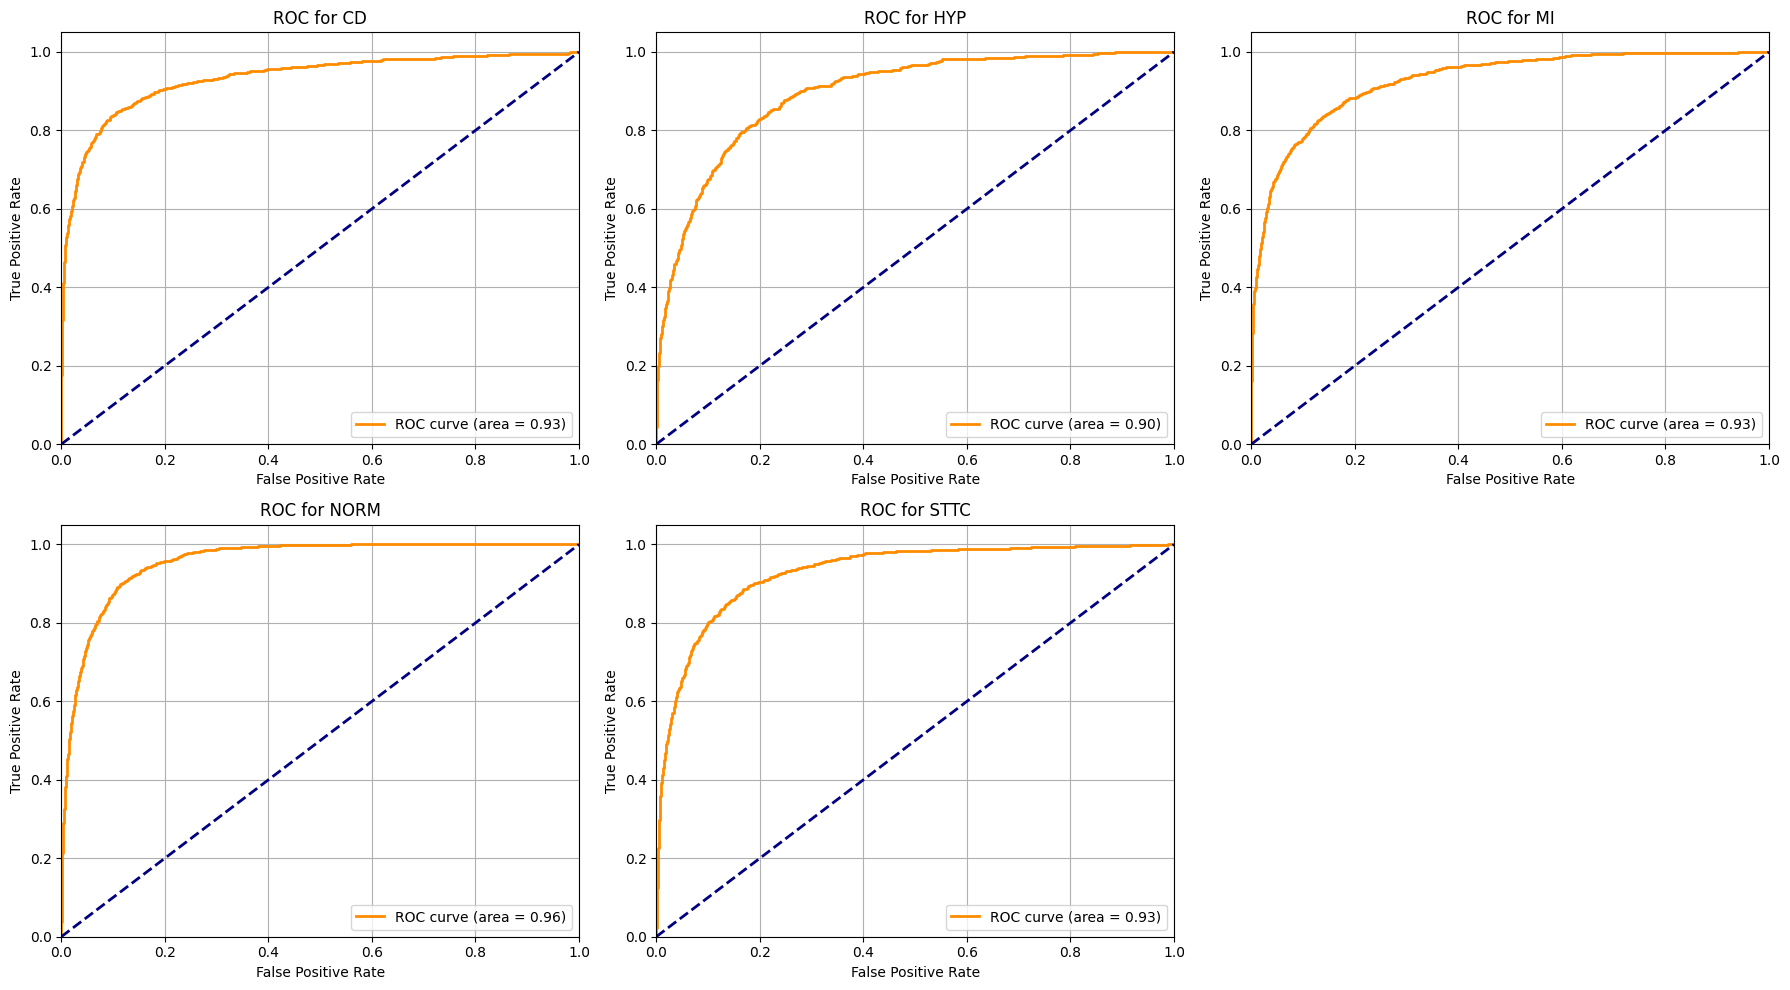

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("\n--- ROC Curves (One-vs-Rest) ---")

num_cols = min(num_classes, 3)
num_rows = int(np.ceil(num_classes / num_cols))

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, class_name in enumerate(all_superclasses):
    plt.subplot(num_rows, num_cols, i + 1)

    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {class_name}')
    plt.legend(loc="lower right")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Stage 4.7: Implement and Visualize Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) helps in understanding which parts of the input signal contribute most to the model's prediction for a specific class. For our 1D CNN, we'll adapt the concept to visualize important time-points/leads in the ECG signal.

In [52]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(ecg_signal, heatmap, class_name, lead_names=None, alpha=0.6):

    plt.figure(figsize=(15, 8))
    if lead_names is None:
        lead_names = [f'Lead {i+1}' for i in range(ecg_signal.shape[1])]

    for i in range(ecg_signal.shape[1]):
        plt.plot(ecg_signal[:, i] + i * 2, label=lead_names[i], alpha=0.8)

    y_min, y_max = plt.gca().get_ylim()
    x_min, x_max = plt.gca().get_xlim()

    plt.imshow(heatmap[np.newaxis, :], cmap='jet', alpha=alpha, aspect='auto',
               extent=[x_min, x_max, y_min, y_max], origin='lower')
    plt.colorbar(label='Activation Importance')

    plt.title(f'Grad-CAM for Class: {class_name}')
    plt.xlabel('Time Points')
    plt.ylabel('Normalized Amplitude (offset for leads)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Run Grad-CAM on a Sample Test ECG

Let's pick a random sample from our test set and visualize the Grad-CAM heatmap for its predicted class. This will show us which parts of the ECG signal contributed most to the model's decision for that particular diagnostic superclass.

Original ECG ID: 10837
Raw predictions: [0.25523326 0.08107238 0.13348597 0.01905777 0.7524004 ]
Predicted class indices (above 0.5 or top): [4]

Generating Grad-CAM for predicted class: STTC


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 1000, 12))
  warnings.warn(msg)


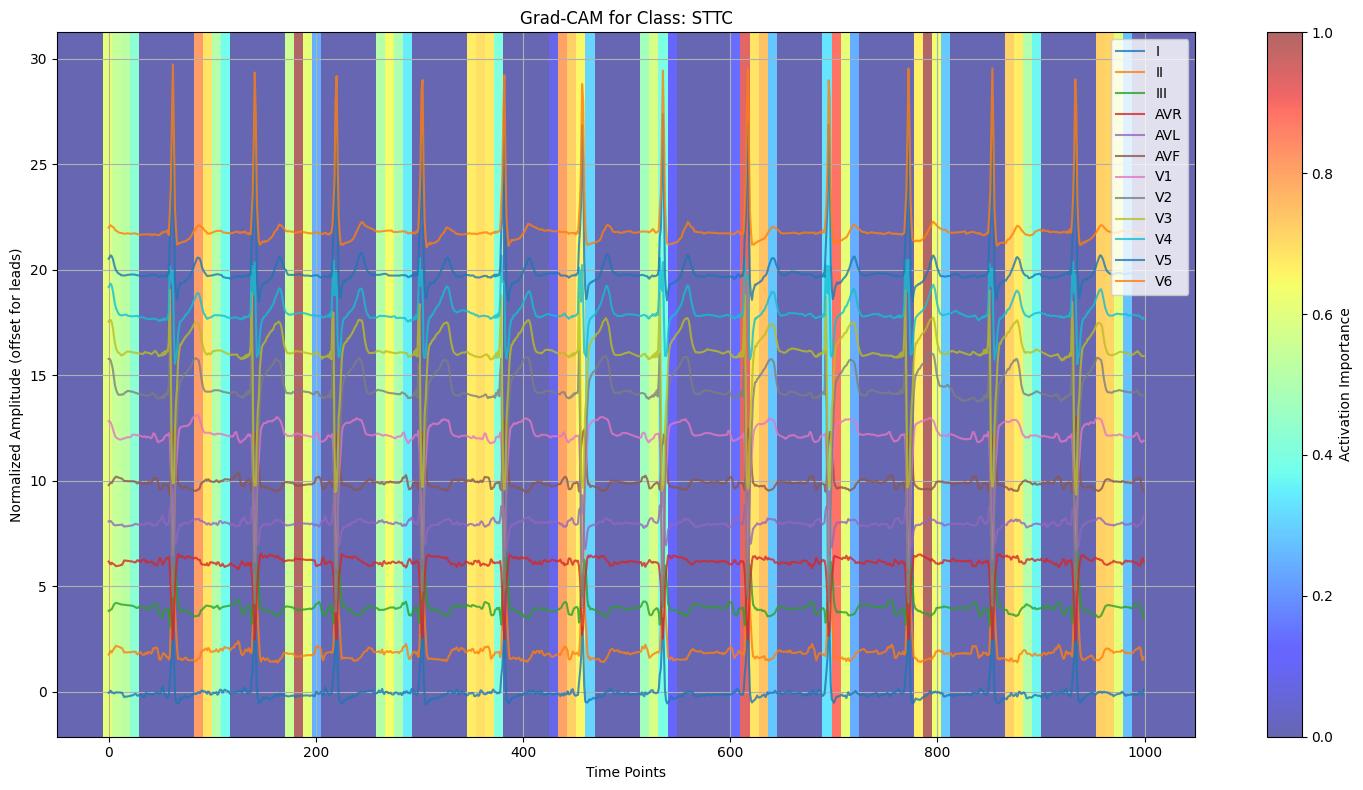

Grad-CAM visualization complete for selected sample(s).


In [53]:
last_conv_layer_name = 'conv1d_3'

if 'sample_test_indices' not in globals():
    num_samples_to_visualize = 5
    np.random.seed(42)
    sample_test_indices = np.random.choice(len(indices_test), num_samples_to_visualize, replace=False)

example_idx_in_test_set = sample_test_indices[0]
original_idx_for_gradcam = indices_test[example_idx_in_test_set]

sample_ecg_for_gradcam = X[original_idx_for_gradcam]

input_ecg_for_model = np.expand_dims(sample_ecg_for_gradcam, axis=0)
predictions_for_sample = best_model.predict(input_ecg_for_model, verbose=0)[0]

predicted_classes_indices = np.where(predictions_for_sample > 0.5)[0]

if len(predicted_classes_indices) == 0:
    print(f"No class predicted above 0.5 threshold for ECG ID {df.loc[original_idx_for_gradcam, 'ecg_id']}. Trying top class.")
    predicted_classes_indices = [np.argmax(predictions_for_sample)]

print(f"Original ECG ID: {df.loc[original_idx_for_gradcam, 'ecg_id']}")
print(f"Raw predictions: {predictions_for_sample}")
print(f"Predicted class indices (above 0.5 or top): {predicted_classes_indices}")

for class_idx in predicted_classes_indices:
    class_name = all_superclasses[class_idx]
    print(f"\nGenerating Grad-CAM for predicted class: {class_name}")

    heatmap = make_gradcam_heatmap(
        input_ecg_for_model,
        best_model,
        last_conv_layer_name,
        pred_index=class_idx
    )

    display_gradcam(
        sample_ecg_for_gradcam,
        heatmap,
        class_name=class_name,
        lead_names=metadata['sig_name'] if 'metadata' in globals() else None
    )


print("Grad-CAM visualization complete for selected sample(s).")

In [45]:
# from google.colab import drive
# drive.mount('/content/drive')


In [46]:
# model.save("/content/drive/MyDrive/ECG_model.keras")